<h1 align="center">
Estimativa de Fase Quântica (QPE)
</h1>

<p align="center">
Implementação do algoritmo de Estimativa de Fase Quântica utilizando Qiskit e Transformada de Fourier Quântica (QFT).
</p>

<p align="center">

<a href="https://colab.research.google.com/drive/1xDv5Bylto3SlpachQPQ2soHlzDZLFX9Z?usp=sharing">
  <img src="https://img.shields.io/badge/Open%20in-Colab-F9AB00?logo=googlecolab&logoColor=white">
</a>

<a href="https://github.com/Lucas-Henriquee/quantum-computing-and-ai/tree/main/quantum_phase_estimation">
  <img src="https://img.shields.io/badge/GitHub-Repository-black?logo=github">
</a>

<a href="https://qiskit.org/">
  <img src="https://img.shields.io/badge/Qiskit-Quantum-purple?logo=qiskit">
</a>

<a href="https://www.python.org/">
  <img src="https://img.shields.io/badge/Python-3.10-blue?logo=python">
</a>


</p>

---
---

## Implementação via Transformada de Fourier Quântica 

---

**Problema:** dado um operador unitário $U$ e um autovetor $|\psi\rangle$ satisfazendo

$$
U|\psi\rangle = e^{2\pi i \varphi}|\psi\rangle,
\qquad \varphi \in [0,1),
$$


o objetivo do algoritmo Quantum Phase Estimation (QPE) é estimar a fase $\varphi$ com $t$ bits de precisão utilizando um registrador de contagem e a aplicação controlada de potências de $U$.

---


| Secao | Conteudo |
|-------|----------|
| 1 | Instalacao e imports |
| 2 | Transformada de Fourier Quantica (QFT) |
| 3 | QFT Inversa |
| 4 | Circuito QPE |
| 5 | Demonstracao: porta T (φ = 1/8) |
| 6 | Precisao da estimativa para φ = 1/3 |
| 7 | Fase racional sem representação binária finita |

In [1118]:
!pip install qiskit qiskit-aer pylatexenc matplotlib numpy --quiet

In [1119]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 2. Transformada de Fourier Quântica (QFT)

### 2.1 Definição

A QFT é a versão quântica da Transformada Discreta de Fourier. Para $N = 2^n$, sua ação sobre a base computacional é:

$$\text{QFT}|j\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i j k / 2^n} |k\rangle$$

### 2.2 Representação em produto tensorial

A QFT admite a seguinte decomposição em produto tensorial:

$$|j_1, \ldots, j_n\rangle \;\longrightarrow\; \frac{\left(|0\rangle + e^{2\pi i\, 0.j_n}|1\rangle\right) \otimes \left(|0\rangle + e^{2\pi i\, 0.j_{n-1}j_n}|1\rangle\right) \otimes \cdots \otimes \left(|0\rangle + e^{2\pi i\, 0.j_1 j_2 \cdots j_n}|1\rangle\right)}{2^{n/2}}$$

onde $0.j_l j_{l+1} \cdots j_m = j_l/2 + j_{l+1}/4 + \cdots + j_m/2^{m-l+1}$ é a fração binária.

### 2.3 Circuito 

A decomposição leva diretamente ao circuito. Para cada qubit $i$:
1. **Hadamard $H$** — cria a superposição com a fase $e^{2\pi i\, 0.j_i}$
2. **Rotações de fase controladas** $R_k = P(2\pi/2^k)$ para cada qubit $j > i$ — acrescentam os bits $j_{i+1}, \ldots, j_n$ à fração binária
3. **SWAPs** ao final — corrigem a ordem dos qubits (a QFT produz os fatores em ordem reversa)

A porta de rotação de fase é:
$$R_k = \begin{pmatrix} 1 & 0 \\ 0 & e^{2\pi i / 2^k} \end{pmatrix}$$

Circuito da QFT para n = 3 qubits:
  Numero de portas : 7
  Complexidade     : O(n^2) = O(9)



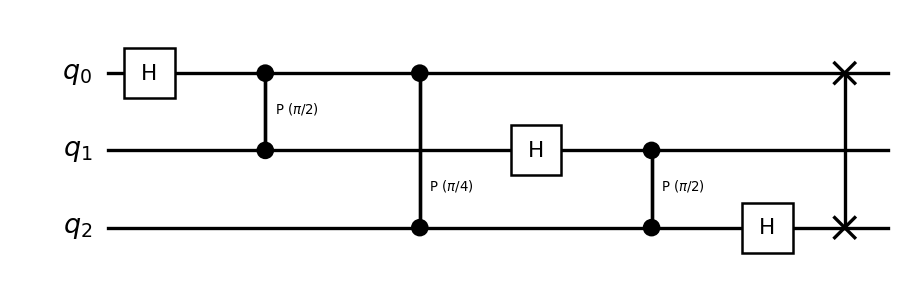

In [ ]:
# Aplica a QFT ao subregistrador indicado

# Parametros:
# circuit : QuantumCircuit
# qubits  : lista de indices dos qubits sobre os quais aplicar a QFT

def qft(circuit, qubits):
    n = len(qubits)

    for i in range(n):
        # Passo 1: Hadamard no qubit i
        # Cria superposicao
        # Corresponde ao primeiro fator de cada qubit
        circuit.h(qubits[i])

        # Passo 2: rotacoes de fase controladas R_k
        # O qubit qubits[j] controla a rotacao aplicada em qubits[i]
        for j in range(i + 1, n):
            k = j - i + 1                    # indice da rotacao R_k
            angle = 2 * np.pi / (2 ** k)     # = pi / 2^{k-1}
            circuit.cp(angle, qubits[j], qubits[i])

    # Passo 3: SWAPs para reverter a ordem dos bits
    # A QFT produz os qubits na ordem inversa; os SWAPs corrigem isso
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - 1 - i])

    return circuit


# Visualizar o circuito da QFT para n = 3 qubits 
n_demo = 3
qc_qft_demo = QuantumCircuit(n_demo)
qft(qc_qft_demo, list(range(n_demo)))

print(f'Circuito da QFT para n = {n_demo} qubits:')
print(f'  Numero de portas : {qc_qft_demo.size()}')
print(f'  Complexidade     : O(n^2) = O({n_demo**2})\n')
fig = qc_qft_demo.draw('mpl', style='bw', fold=50)
fig.savefig('fig_circuito_qft.png', dpi=800, bbox_inches='tight')
fig


## 3. QFT Inversa

A QFT é unitária, portanto sua inversa é o operador adaga:

$$\text{QFT}^{-1} = \text{QFT}^\dagger$$

No circuito: aplicamos as operações da QFT **na ordem inversa**, substituindo cada
$R_k = P(2\pi/2^k)$ pelo seu adaga $R_k^\dagger = P(-2\pi/2^k)$.

A $\text{QFT}^{-1}$ é a operação central da **Etapa 3 do QPE**.

**Verificação numérica:** se $\text{QFT} \cdot \text{QFT}^\dagger = I$, a implementação está correta.

In [1121]:
# Aplica a QFT inversa (QFT dag) ao subregistrador indicado
# Passos:
#  1. Desfaz os SWAPs do final da QFT
#  2. Aplica as operações da QFT em ordem inversa, com ângulos negativos

def qft_inverse(circuit, qubits):

    n = len(qubits)

    # Desfaz os SWAPs
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - 1 - i])

    # Operações da QFT em ordem inversa, com ângulos negativos
    for i in range(n - 1, -1, -1):
        # Rotações inversas: P(-2*pi/2^k) = adaga de P(2*pi/2^k)
        for j in range(n - 1, i, -1):
            k = j - i + 1
            angle = -2 * np.pi / (2 ** k)   
            circuit.cp(angle, qubits[j], qubits[i])

        # H dag = H 
        circuit.h(qubits[i])

    return circuit

In [1122]:
# Verificacao: QFT * QFT_dag = Identidade
n_check = 3
qc_check = QuantumCircuit(n_check)
qft(qc_check, list(range(n_check)))
qft_inverse(qc_check, list(range(n_check)))

op    = Operator(qc_check)
is_id = np.allclose(op.data, np.eye(2**n_check), atol=1e-10)
err   = np.max(np.abs(op.data - np.eye(2**n_check)))

print(f'QFT * QFT_dag == Identidade? {"SIM" if is_id else "NAO"}')
print(f'Erro maximo nas entradas da matriz: {err:.2e}')

QFT * QFT_dag == Identidade? SIM
Erro maximo nas entradas da matriz: 4.44e-16


## 4. Circuito QPE

### Estrutura do algoritmo 

O QPE usa **dois registradores**:

| Registrador | Qubits | Estado inicial | Papel |
|------------|--------|---------------|-------|
| Contagem | $t$ | $0\rangle^{\otimes t}$ | Armazena a estimativa de $\varphi$ |
| Alvo | $\geq 1$ | $\psi\rangle$ (autovetor de $U$) | Fonte da fase |

**Etapa 1 — Preparação:**

$$|0\rangle^{\otimes t}|\psi\rangle \;\xrightarrow{H^{\otimes t}}\; \frac{1}{\sqrt{2^t}}\sum_{j=0}^{2^t - 1}|j\rangle\,|\psi\rangle$$

**Etapa 2 — Portas $\text{controlled-}U^{2^k}$:**

Potências sucessivas de $U$ são aplicadas de forma controlada aos qubits de contagem, respeitando a ordem de bits esperada pela $\text{QFT}^{-1}$.

Como

$$
U|\psi\rangle = e^{2\pi i\varphi}|\psi\rangle,
$$

segue que

$$
U^{2^k}|\psi\rangle
=
e^{2\pi i \cdot 2^k\varphi}|\psi\rangle.
$$

Assim, a informação de fase é codificada no registrador de contagem, produzindo o estado

$$
\frac{1}{\sqrt{2^t}}
\sum_{j=0}^{2^t - 1}
e^{2\pi i \varphi j}
|j\rangle |\psi\rangle.
$$


**Etapa 3 — $\text{QFT}^{-1}$ e medição:**

A $\text{QFT}^{-1}$ converte o estado acima em $|\tilde\varphi\rangle$, a melhor aproximação de $\varphi \cdot 2^t$ em binário. A medição retorna $\tilde\varphi$ com probabilidade $\geq 1 - \varepsilon$.

In [1123]:
# Constrói o circuito QPE completo 

# Parametros
#
# controlled_u_func : funcao(circuit, control_qubit, target_qubits)
    #  Adiciona uma aplicacao de controlled-U ao circuito
    #  Sera chamada 2^k vezes para o qubit de controle k
# prepare_eigenstate_func : funcao(circuit, target_qubits)
    #  Prepara o autovetor |psi> no registrador alvo
# n_counting :
    # Numero de qubits de contagem t (= bits de precisao da estimativa)
# n_target :
    # Numero de qubits no registrador alvo

def build_qpe_circuit(controlled_u_func, prepare_eigenstate_func,
                      n_counting, n_target=1):
   
    counting  = QuantumRegister(n_counting, name='contagem')
    target    = QuantumRegister(n_target,   name='alvo')
    classical = ClassicalRegister(n_counting, name='resultado')

    qc = QuantumCircuit(counting, target, classical)

    # Etapa 1: H^t no registrador de contagem
    # Cria superposicao uniforme
    qc.h(counting)

    # Etapa 1b: preparar autovetor |psi> no registrador alvo
    prepare_eigenstate_func(qc, target)

    qc.barrier(label='Preparação')

    # Etapa 2: portas controlled-U^{2^k}
    # Pela convenção de ordem dos qubits usada na QFT inversa,
    # counting[k] controla U^{2^(n_counting - 1 - k)}
    # Implementamos U^{2^k} aplicando U exatamente 2^k vezes
    for k in range(n_counting):
        power = 2 ** (n_counting - 1 - k)
        for _ in range(power):
            controlled_u_func(qc, counting[k], target)

    qc.barrier(label='controlled-U')

    # Etapa 3: QFT^{-1} no registrador de contagem
    # Converte sum e^{2pi*i*phi*j}|j> em |phi_tilde> 
    qft_inverse(qc, list(range(n_counting)))

    qc.barrier(label='Medição')

    # Medicao do registrador de contagem
    qc.measure(counting, classical)

    return qc

In [1124]:
# Executa o circuito QPE no simulador classico do Qiskit (AerSimulator)
def run_qpe(qc, shots=8192):
    simulator = AerSimulator()
    result = simulator.run(qc, shots=shots).result()
    return result.get_counts()

In [1125]:
# Converte a string de bits medida em fase estimada
# Qiskit usa convencao little-endian: o bit menos significativo
# vem primeiro na string. Revertemos para obter o inteiro correto.

def decode_phase(bitstring, n_bits):
    bits    = bitstring[::-1]      
    decimal = int(bits, 2)
    return decimal / (2 ** n_bits)

In [1126]:
# Exibe os resultados do QPE
def show_results(counts, n_counting, phi_true, top_k=5):
    total = sum(counts.values())
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

    print(f"{'Bits medidos':<15} {'Decimal':>8} {'phi estimada':>14}"
          f" {'|phi - phi_est|':>16} {'Prob.':>8}")
    print('-' * 68)

    for bits, cnt in sorted_counts[:top_k]:
        dec   = int(bits[::-1], 2)
        phi_e = dec / (2 ** n_counting)
        erro  = abs(phi_e - phi_true)
        prob  = cnt / total
        tag   = ' <-- melhor' if bits == sorted_counts[0][0] else ''
        print(f"{bits:<15} {dec:>8} {phi_e:>14.6f}"
              f" {erro:>16.2e} {prob:>7.1%}{tag}")

    best = decode_phase(sorted_counts[0][0], n_counting)
    print(f'\n  phi verdadeira : {phi_true:.8f}')
    print(f'  phi estimada   : {best:.8f}')
    print(f'  Erro absoluto  : {abs(best - phi_true):.2e}')
    print(f'  Cota 1/2^t     : {1/2**n_counting:.2e}')
    return best

## 5. Demonstração: porta T com fase exata $\varphi = 1/8$

A porta $T$ (porta $\pi/8$) e definida como:

$$T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix} = P\!\left(\frac{\pi}{4}\right)$$

O estado $|1\rangle$ é autovetor de $T$ com autovalor $e^{i\pi/4} = e^{2\pi i (1/8)}$:

$$T|1\rangle = e^{2\pi i (1/8)}|1\rangle \quad \Longrightarrow \quad \varphi = \frac{1}{8} = 0.001_2$$

Como $\varphi = 1/8$ e representável **exatamente** em 3 bits binários, com $t = 3$ qubits de contagem o QPE deve retornar o resultado correto com **probabilidade 1** (resultado deterministico).

Circuito QPE -- Porta T | t = 3 qubits de contagem
  Qubits totais : 4  (3 contagem + 1 alvo)
  Portas totais : 21



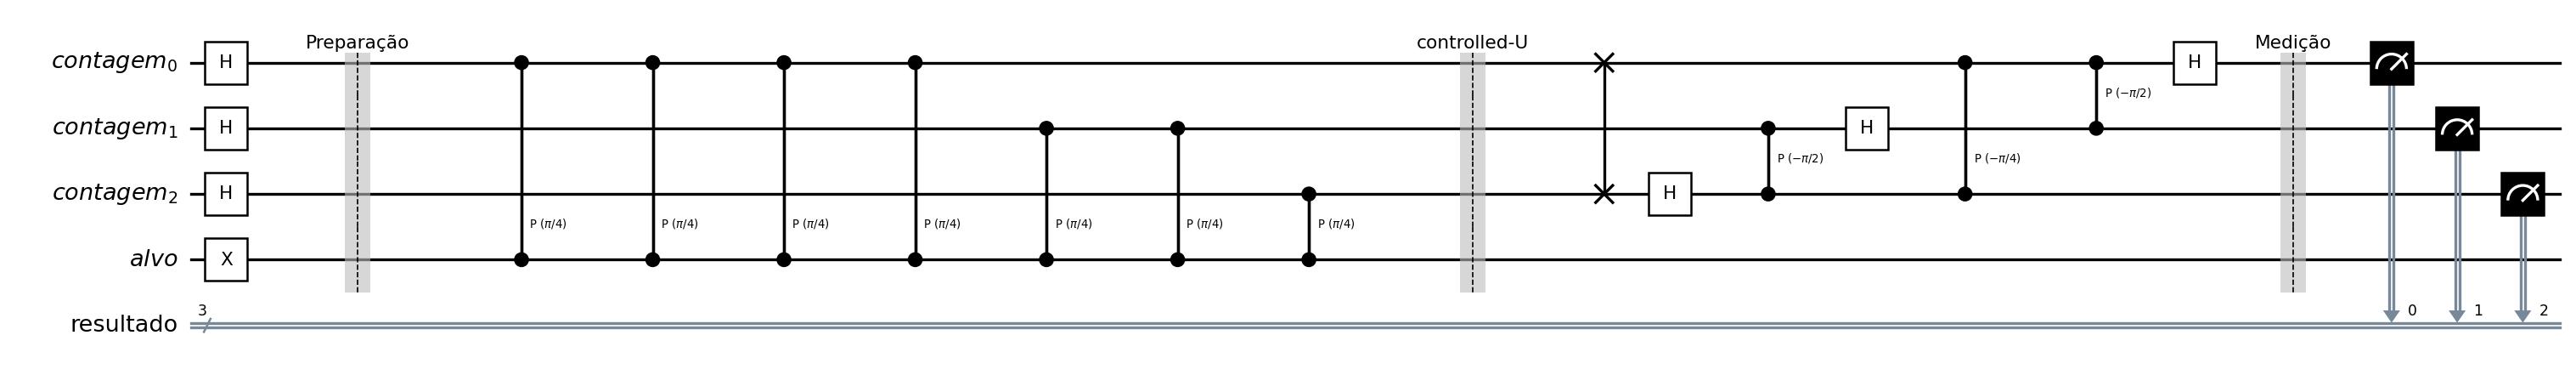

In [1127]:
# Parâmetros
PHI_TRUE   = 1 / 8    # fase verdadeira
N_COUNTING = 3        # t = 3 bits de precisao

# Controlled-T: CP(pi/4). Implementa e^{2*pi*i/8} no qubit alvo
def t_gate_controlled(circuit, control, target_reg):
    circuit.cp(np.pi / 4, control, target_reg[0])

# Prepara |1> no qubit alvo: autovetor de T com phi = 1/8
def prepare_eigenstate_1(circuit, target_reg):
    circuit.x(target_reg[0])    # X|0> = |1>

# Construir e visualizar o circuito QPE
qc_t = build_qpe_circuit(
    controlled_u_func       = t_gate_controlled,
    prepare_eigenstate_func = prepare_eigenstate_1,
    n_counting              = N_COUNTING
)

print(f'Circuito QPE -- Porta T | t = {N_COUNTING} qubits de contagem')
print(f'  Qubits totais : {qc_t.num_qubits}  ({N_COUNTING} contagem + 1 alvo)')
print(f'  Portas totais : {qc_t.size()}\n')

fig = qc_t.draw('mpl', style='bw', fold=50, scale=1.0)
fig.savefig('fig_circuito_qpe.png', dpi=800, bbox_inches='tight')
fig

Resultados QPE -- Porta T (phi = 0.125)

Bits medidos     Decimal   phi estimada  |phi - phi_est|    Prob.
--------------------------------------------------------------------
100                    1       0.125000         0.00e+00  100.0% <-- melhor

  phi verdadeira : 0.12500000
  phi estimada   : 0.12500000
  Erro absoluto  : 0.00e+00
  Cota 1/2^t     : 1.25e-01


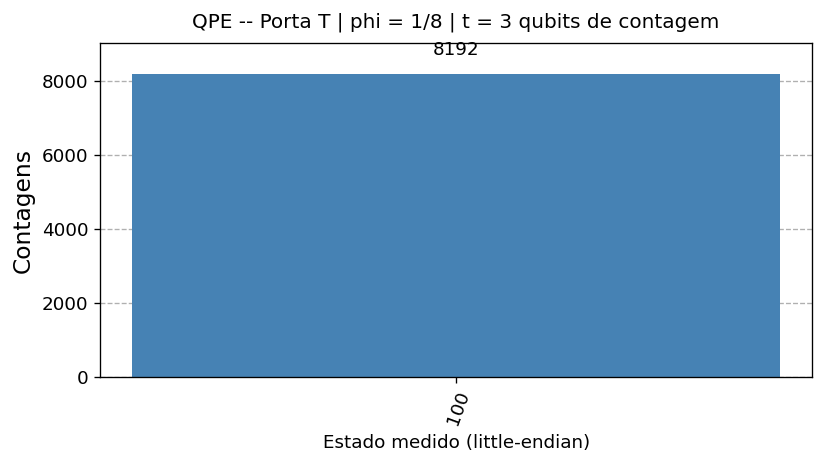


Com fase exata (phi = 1/8 = 0.001_2), o QPE e deterministico.
Distribuicao teorica: P("100") = 1.0


In [1128]:
# Executar simulacao no AerSimulator e analisar resultados
SHOTS    = 8192
counts_t = run_qpe(qc_t, shots=SHOTS)

print(f'Resultados QPE -- Porta T (phi = {PHI_TRUE})\n')
phi_est = show_results(counts_t, N_COUNTING, PHI_TRUE)

# Histograma de probabilidades
fig, ax = plt.subplots(figsize=(7, 4))
plot_histogram(counts_t, ax=ax, color='steelblue', title='')
ax.set_title(
    f'QPE -- Porta T | phi = 1/8 | t = {N_COUNTING} qubits de contagem',
    fontsize=12, pad=10
)
ax.set_xlabel('Estado medido (little-endian)')
ax.set_ylabel('Contagens')
plt.tight_layout()
plt.savefig('fig_histograma_T.png', dpi=800, bbox_inches='tight')
plt.show()

print('\nCom fase exata (phi = 1/8 = 0.001_2), o QPE e deterministico.')
print('Distribuicao teorica: P("100") = 1.0')

## 6. Precisao: relacao entre qubits de contagem e erro

Do **Teorema 5.1** de N&C (§5.2.1): para obter $\varphi$ com $n$ bits de precisao e probabilidade de sucesso $\geq 1 - \varepsilon$, sao necessarios

$$t = n + \left\lceil \log_2\!\left(2 + \frac{1}{2\varepsilon}\right) \right\rceil \text{ qubits de contagem.}$$

O erro de estimativa satisfaz:

$$|\varphi - \tilde{\varphi}| \leq \frac{1}{2^n} \quad \text{com probabilidade} \geq 1 - \varepsilon.$$

Verificamos empiricamente para φ = 1/3, que não possui representação binária finita, variando t de 1 a 5.

phi verdadeira = 0.3333333333 = 1/3 (racional, mas sem representação binária finita)

  t   phi estimada       Erro  P(melhor)   Cota 1/2^t
-------------------------------------------------------
  1       0.500000   1.67e-01     75.6%     5.00e-01
  2       0.250000   8.33e-02     69.8%     2.50e-01
  3       0.375000   4.17e-02     69.3%     1.25e-01
  4       0.312500   2.08e-02     68.4%     6.25e-02
  5       0.343750   1.04e-02     68.7%     3.12e-02


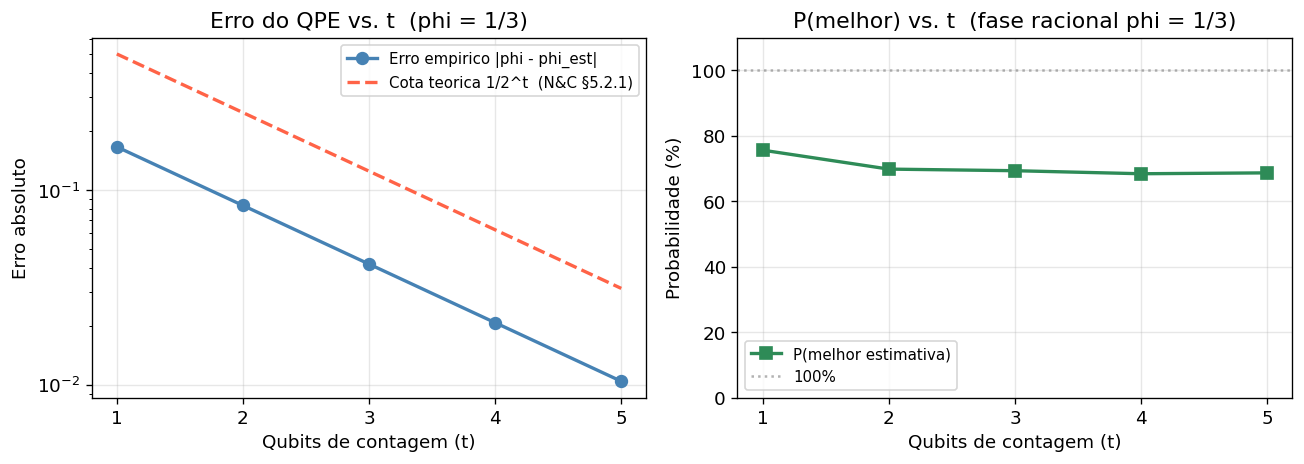


Como phi = 1/3 é racional, mas não possui representação binária finita, o erro nunca chega exatamente a zero.
O erro fica sempre abaixo da cota 1/2^t.
Mais qubits de contagem melhoram a precisão da estimativa.


In [1129]:
# Experimento: erro empirico vs. numero de qubits de contagem
PHI_TEST = 1 / 3
t_values = range(1, 6)

# Porta correta para phi = 1/3: CP(2*pi*phi) no qubit alvo
def phase_13_controlled(circuit, control, target_reg):
    circuit.cp(2 * np.pi * PHI_TEST, control, target_reg[0])

print(f'phi verdadeira = {PHI_TEST:.10f} = 1/3 (racional, mas sem representação binária finita)\n')
print(f'{"t":>3} {"phi estimada":>14} {"Erro":>10} {"P(melhor)":>10} {"Cota 1/2^t":>12}')
print('-' * 55)

erros = []
probs = []

for t in t_values:
    qc_prec   = build_qpe_circuit(phase_13_controlled, prepare_eigenstate_1, n_counting=t)
    counts    = run_qpe(qc_prec, shots=4096)
    total     = sum(counts.values())
    m_best = round(PHI_TEST * 2**t) % (2**t)
    phi_best = m_best / (2 ** t)
    erro = abs(phi_best - PHI_TEST)
    best_bits = format(m_best, f'0{t}b')[::-1]
    prob = counts.get(best_bits, 0) / total
    cota      = 1 / (2 ** t)
    erros.append(erro)
    probs.append(prob)
    print(f'{t:>3} {phi_best:>14.6f} {erro:>10.2e} {prob:>9.1%} {cota:>12.2e}')

# Graficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
t_arr    = np.array(list(t_values))
cota_arr = 1 / 2 ** t_arr

# Erro vs. t
ax1.semilogy(t_arr, erros, 'o-', color='steelblue',
             linewidth=2, markersize=7, label='Erro empirico |phi - phi_est|')
ax1.semilogy(t_arr, cota_arr, '--', color='tomato', linewidth=2,
             label='Cota teorica 1/2^t  (N&C §5.2.1)')
ax1.set_xlabel('Qubits de contagem (t)')
ax1.set_ylabel('Erro absoluto')
ax1.set_title('Erro do QPE vs. t  (phi = 1/3)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(t_arr)

# Probabilidade da melhor estimativa vs. t
ax2.plot(t_arr, [p * 100 for p in probs], 's-', color='seagreen',
         linewidth=2, markersize=7, label='P(melhor estimativa)')
ax2.axhline(100, color='gray', linestyle=':', alpha=0.6, label='100%')
ax2.set_xlabel('Qubits de contagem (t)')
ax2.set_ylabel('Probabilidade (%)')
ax2.set_title('P(melhor) vs. t  (fase racional phi = 1/3)')
ax2.set_ylim(0, 110)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(t_arr)

plt.tight_layout()
plt.savefig('qpe_precision.png', dpi=800, bbox_inches='tight')
plt.show()

print('\nComo phi = 1/3 é racional, mas não possui representação binária finita, o erro nunca chega exatamente a zero.')
print('O erro fica sempre abaixo da cota 1/2^t.')
print('Mais qubits de contagem melhoram a precisão da estimativa.')

## 7. Fase racional sem representação binária finita: φ = 1/3 e análise da distribuição de probabilidades

Ao contrário de φ = 1/8, a fração φ = 1/3 **não é representável exatamente**
em binário com número finito de bits. O QPE retorna uma distribuição de
probabilidades centrada no inteiro mais próximo de φ · 2^t.

A amplitude de medir o estado |(b + l) mod 2^t⟩ é:

$$\alpha_l = \frac{1}{2^t} \cdot \frac{1 - e^{2\pi i (2^t \delta - l)}}{1 - e^{2\pi i (\delta - l/2^t)}}$$

onde

$$
b = \operatorname{round}(\varphi \cdot 2^t)
$$

é o inteiro mais próximo de $\varphi \cdot 2^t$, e a estimativa da fase é dada por

$$
\tilde{\varphi} = \frac{b}{2^t}.
$$

O erro da aproximação satisfaz

$$
\left|\varphi - \tilde{\varphi}\right| \leq \frac{1}{2^{t+1}}.
$$

A probabilidade teórica de medir o estado $m$ é $|\alpha_{m-b}|^2$.
Verificamos a seguir que o simulador reproduz essa distribuição.

QPE — φ = 1/3 ≈ 0.333333 | t = 4 qubits

Bits medidos     Decimal   phi estimada  |phi - phi_est|    Prob.
--------------------------------------------------------------------
1010                   5       0.312500         2.08e-02   68.1% <-- melhor
0110                   6       0.375000         4.17e-02   17.5%
0010                   4       0.250000         8.33e-02    4.7%
1110                   7       0.437500         1.04e-01    2.9%
1100                   3       0.187500         1.46e-01    1.5%

  phi verdadeira : 0.33333333
  phi estimada   : 0.31250000
  Erro absoluto  : 2.08e-02
  Cota 1/2^t     : 6.25e-02


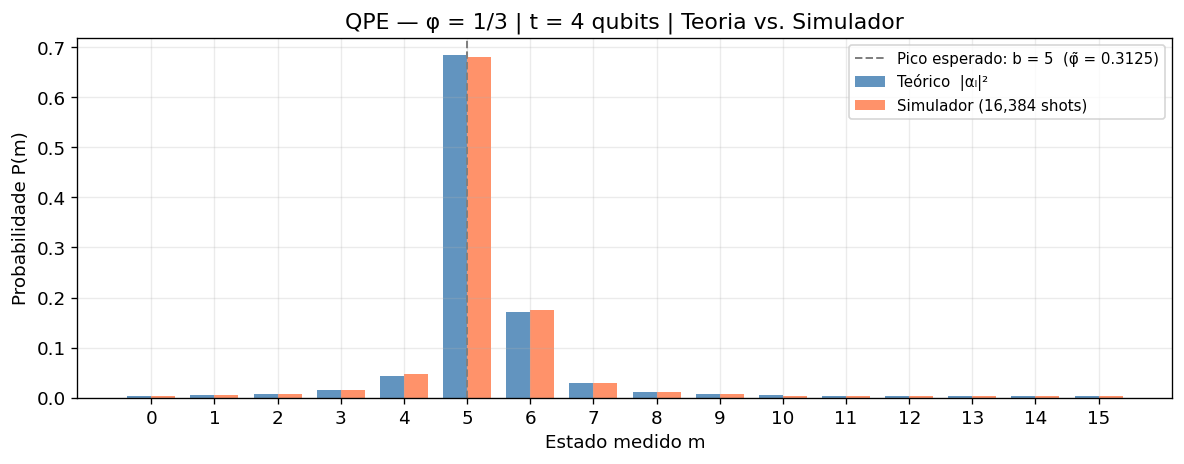


Melhor estimativa : φ̃ = 0.312500
Fase verdadeira   : φ  = 0.333333
Erro absoluto     : 2.08e-02  (cota 1/2^t = 6.25e-02)


In [1130]:
# Parâmetros 
PHI_ARB    = 1 / 3
N_COUNT_ARB = 4
SHOTS_ARB  = 16384

# Controlled-P(2π·φ): autovalor e^{2πi/3}, autoestado |1⟩ 
def phase_arb_controlled(circuit, control, target_reg):
    circuit.cp(2 * np.pi * PHI_ARB, control, target_reg[0])

# Rodar QPE
qc_arb = build_qpe_circuit(phase_arb_controlled, prepare_eigenstate_1,
                            n_counting=N_COUNT_ARB)
counts_arb = run_qpe(qc_arb, shots=SHOTS_ARB)

print(f'QPE — φ = 1/3 ≈ {PHI_ARB:.6f} | t = {N_COUNT_ARB} qubits\n')
show_results(counts_arb, N_COUNT_ARB, PHI_ARB)

# Distribuição teórica P(m) = |α_{m-b}|² 
N = 2 ** N_COUNT_ARB
b = round(PHI_ARB * N) % N              # melhor aproximação inteira de φ·2^t
delta = PHI_ARB - b / N           # δ = φ - b/2^t

# Probabilidade teórica de medir m, via eq. 5.25 do N&C
def prob_teorica(m, b, delta, N):
    l = (m - b) % N               # deslocamento em relação ao pico
    if l > N // 2:
        l -= N                    # tomar o mais próximo de zero
    expoente = 2 * np.pi * (delta - l / N)
    if abs(expoente) < 1e-12:
        return 1.0                # limite: l=0 e δ→0 (fase exata)
    num = abs(1 - np.exp(1j * 2 * np.pi * (N * delta - l)))
    den = abs(1 - np.exp(1j * expoente))
    return (num / (N * den)) ** 2

estados   = list(range(N))
p_teorica = [prob_teorica(m, b, delta, N) for m in estados]

# Probabilidade empírica
total = sum(counts_arb.values())
p_empirica = []
for m in estados:
    bits = format(m, f'0{N_COUNT_ARB}b')[::-1]   # little-endian (Qiskit)
    p_empirica.append(counts_arb.get(bits, 0) / total)

#Gráfico: teoria vs. simulador 
x = np.arange(N)
largura = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - largura/2, p_teorica,  largura, label='Teórico  |αₗ|²',
       color='steelblue', alpha=0.85)
ax.bar(x + largura/2, p_empirica, largura, label=f'Simulador ({SHOTS_ARB:,} shots)',
       color='coral',     alpha=0.85)

ax.axvline(b, color='gray', linestyle='--', linewidth=1.2,
           label=f'Pico esperado: b = {b}  (φ̃ = {b/N:.4f})')
ax.set_xlabel('Estado medido m')
ax.set_ylabel('Probabilidade P(m)')
ax.set_title(f'QPE — φ = 1/3 | t = {N_COUNT_ARB} qubits | Teoria vs. Simulador')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('qpe_teoria_vs_simulador.png', dpi=800, bbox_inches='tight')
plt.show()

print(f'\nMelhor estimativa : φ̃ = {b/N:.6f}')
print(f'Fase verdadeira   : φ  = {PHI_ARB:.6f}')
print(f'Erro absoluto     : {abs(b/N - PHI_ARB):.2e}  (cota 1/2^t = {1/N:.2e})')